In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import subprocess

ADMIXTURE and STRUCTURE analyses to pair with the FEEMS analysis:

In [2]:
!mkdir -p ../admixture_structure_input_final

In [4]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz \
    --make-bed \
    --out ../admixture_structure_input_final/admixture_in

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../admixture_structure_input_final/admixture_in.log.
Options in effect:
  --make-bed
  --out ../admixture_structure_input_final/admixture_in
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz

Start time: Tue Apr 28 16:16:53 2026
771373 MiB RAM detected, ~725776 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 3215 variants scanned.
--vcf: ../admixture_structure_input_final/admixture_in-temporary.pgen +
../admixture_structure_input_final/admixture_in-temporary.pvar.zst +
../admixture_structure_input_final/admixture_in-temporary.psam written.
554 samples (0 females, 0 males, 554 ambiguous; 554 founders) loaded from
../admixture_structure_input_final/admixture_in-temporary.psam.
Note: 14 nonstandard ch

ADMIXTURE hates non-integer chromosome names, so we fix that here in the bim files:

In [5]:
%%bash
awk 'BEGIN{FS=OFS="\t"} {gsub(/^NC_/, "", $1); gsub(/\.1$/, "", $1); print}' ../admixture_structure_input_final/admixture_in.bim \
    > ../admixture_structure_input_final/admixture_in_fixed.bim
cp ../admixture_structure_input_final/admixture_in.bed \
    ../admixture_structure_input_final/admixture_in_fixed.bed
cp ../admixture_structure_input_final/admixture_in.fam \
    ../admixture_structure_input_final/admixture_in_fixed.fam

In [6]:
!mkdir -p ../admixture_final

In [7]:
%%bash
source ~/.bashrc
conda activate ipyrad
cd ../admixture_final
for K in 1 2 3 4 5 6 7 8 9 10 11 12; do
    admixture -j8 --cv=10 --seed=123456 \
        ../admixture_structure_input_final/admixture_in_fixed.bed ${K} \
        | tee admixture_in_fixed.${K}.log
done

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 8 threads.
Cross-validation will be performed.  Folds=10.
Random seed: 123456
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 554x3215
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 0.061	Loglikelihood: -2.12821e+06	(delta): 1.

In [2]:
vcf = pd.read_csv("../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz", 
                  sep = "\t", comment = "#", header = None, compression = "gzip")
for i in vcf.columns[9:]:
    vcf[i] = vcf[i].str.split(":", n = 1, expand = True)[0]
alleles = {"0/0":"1\t1","0/1":"1\t2","1/0":"1\t2","1/1":"2\t2","./.":"-9\t-9"}
vcf = vcf[[2] + vcf.columns[9:].tolist()].set_index(2).T
for i in vcf.columns[:].tolist():
    vcf.loc[vcf[i] == "0/0", i] = alleles["0/0"]
    vcf.loc[vcf[i] == "1/0", i] = alleles["1/0"]
    vcf.loc[vcf[i] == "0/1", i] = alleles["0/1"]
    vcf.loc[vcf[i] == "1/1", i] = alleles["1/1"]
    vcf.loc[vcf[i] == "./.", i] = alleles["./."]

In [3]:
vcf = vcf.reset_index(drop=True).reset_index(drop=False)

In [10]:
vcf.set_index(vcf.columns[0]).to_csv("../admixture_structure_input_final/snpchip.str", sep = "\t", header = None)

In [11]:
!sed -i "s/\"//g" ../admixture_structure_input_final/snpchip.str

In [12]:
!zgrep "^#" ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered_downsampled_maffiltered_ldfiltered.vcf.gz \
    | tail -1 | cut -f10- | tr "\t" "\n" > ../admixture_structure_input_final/sample_list.txt

In [4]:
samples = pd.read_csv("../admixture_structure_input_final/sample_list.txt", header = None, names = ["id"])

In [5]:
galmet = pd.read_csv("../030426_all_sample_data.tabular", sep = "\t")
galmet.loc[galmet["Reef Name"] == "Veracruz", "Region"] = "Mexico"
galmet = galmet[["Affymetrix ID", "Region"]]
galmet.columns = ["id", "Region"]
samples = samples.merge(galmet[["id", "Region"]], how = "left", on = "id")

In [6]:
samples.loc[samples["Region"].isna(), "Region"] = "USVI"

In [7]:
pos = 0
for i in samples["Region"].unique():
    pos = pos + 1
    samples.loc[samples["Region"] == i, "Region_id"] = pos
samples["Region_id"] = samples["Region_id"].astype(int)
samples = samples.reset_index(drop=False)
samples["sample_id"] = samples["Region"].str.replace(" ", "") + samples["index"].astype(str)
samples[["sample_id", "Region_id"]].set_index("sample_id").to_csv("../admixture_structure_input_final/adjusted_sample_list.txt", 
                                                                  sep = "\t", header = None)

In [17]:
!paste ../admixture_structure_input_final/adjusted_sample_list.txt \
    <( cut -f2- ../admixture_structure_input_final/snpchip.str ) \
    > ../admixture_structure_input_final/snpchip_final.str

In [22]:
!mkdir -p ../structure_locprior0_nohetoutlier_final

In [25]:
%%bash
echo -e "#define NUMINDS 554
#define NUMLOCI 3215
#define MISSING -9
#define LABEL 1
#define ONEROWPERIND 1
#define PHENOTYPE 0
#define POPDATA 1
#define POPFLAG 0
#define EXTRACOLS 0
#define MARKERNAMES 0
#define BURNIN 50000
#define NUMREPS 50000" > ../structure_locprior0_nohetoutlier_final/mainparams

In [26]:
%%bash
echo -e "#define LOCISPOP 1
#define LOCPRIOR 0
#define NOADMIX 0
#define RANDOMIZE 0
#define USEPOPINFO 0" > ../structure_locprior0_nohetoutlier_final/extraparams

In [27]:
%%bash
cp ../admixture_structure_input_final/snpchip_final.str ../structure_locprior0_nohetoutlier_final/

In [28]:
seeds = random.sample(list(range(0,2000)), 128)
print(seeds)

[762, 627, 600, 384, 1303, 245, 813, 688, 1376, 1361, 670, 37, 456, 822, 1792, 1643, 1282, 126, 1548, 135, 610, 1732, 1515, 408, 1513, 1093, 1691, 251, 1720, 1915, 625, 1164, 101, 30, 974, 1875, 1579, 124, 57, 1295, 1780, 1716, 1334, 640, 513, 223, 1169, 921, 829, 1504, 122, 239, 789, 1015, 1971, 891, 138, 1937, 635, 1750, 1149, 378, 396, 1475, 1689, 1454, 1446, 752, 1173, 1558, 488, 1416, 987, 1089, 683, 978, 1653, 463, 1586, 1724, 1268, 943, 1096, 1057, 779, 1099, 1092, 105, 1126, 1211, 1572, 1771, 850, 1702, 1135, 1991, 435, 698, 1030, 1594, 957, 312, 116, 390, 1031, 455, 1414, 1025, 849, 560, 796, 1623, 1240, 394, 1722, 911, 864, 1304, 867, 1112, 927, 170, 570, 81, 1952, 1907, 634, 578]


In [29]:
pos = 0
for k in list(range(1,13)):
    for rep in list(range(1,11)): 
        for path in ["admixture_final"]:
            task = "admixture"
            mem = "8"
            cpus = "4"
            inprefix = "/fs/dss/work/noge4093/apal_popgen/admixture_structure_input_final/admixture_in_fixed"
            outdir = "/fs/dss/work/noge4093/apal_popgen/" + path
            kval = k
            rep = rep
            seed = seeds[pos]
            subprocess.run(["sbatch --mem=" + mem + "g --ntasks=" + 
                 cpus + " ../" + task + ".sh " + 
                 inprefix + " " + outdir + " " + str(kval) + " " + str(rep) + " " + str(seed)], shell=True)
            pos = pos + 1

Submitted batch job 16473206
Submitted batch job 16473207
Submitted batch job 16473208
Submitted batch job 16473209
Submitted batch job 16473210
Submitted batch job 16473211
Submitted batch job 16473212
Submitted batch job 16473213
Submitted batch job 16473214
Submitted batch job 16473215
Submitted batch job 16473216
Submitted batch job 16473217
Submitted batch job 16473218
Submitted batch job 16473219
Submitted batch job 16473220
Submitted batch job 16473221
Submitted batch job 16473222
Submitted batch job 16473223
Submitted batch job 16473224
Submitted batch job 16473225
Submitted batch job 16473226
Submitted batch job 16473227
Submitted batch job 16473228
Submitted batch job 16473229
Submitted batch job 16473230
Submitted batch job 16473231
Submitted batch job 16473232
Submitted batch job 16473233
Submitted batch job 16473234
Submitted batch job 16473235
Submitted batch job 16473236
Submitted batch job 16473237
Submitted batch job 16473238
Submitted batch job 16473239
Submitted batc

In [31]:
pos = 0
for k in list(range(1,13)):
    for rep in list(range(1,11)): 
        for path in ["structure_locprior0_nohetoutlier_final"]:
            task = "structure"
            mem = "8"
            cpus = "1"
            inpath = "/fs/dss/work/noge4093/apal_popgen/" + path
            infile = "snpchip_final.str"
            kval = k
            rep = rep
            seed = seeds[pos]
            subprocess.run(["sbatch --mem=" + mem + "g --ntasks=" + 
                 cpus + " ../" + task + ".sh " + 
                 inpath + " " + infile + " " + str(kval) + " " + str(rep) + " " + str(seed)], shell=True)
            pos = pos + 1

Submitted batch job 16473327
Submitted batch job 16473328
Submitted batch job 16473329
Submitted batch job 16473330
Submitted batch job 16473331
Submitted batch job 16473332
Submitted batch job 16473333
Submitted batch job 16473334
Submitted batch job 16473335
Submitted batch job 16473336
Submitted batch job 16473337
Submitted batch job 16473338
Submitted batch job 16473339
Submitted batch job 16473340
Submitted batch job 16473341
Submitted batch job 16473342
Submitted batch job 16473343
Submitted batch job 16473344
Submitted batch job 16473345
Submitted batch job 16473346
Submitted batch job 16473347
Submitted batch job 16473348
Submitted batch job 16473349
Submitted batch job 16473350
Submitted batch job 16473351
Submitted batch job 16473352
Submitted batch job 16473353
Submitted batch job 16473354
Submitted batch job 16473355
Submitted batch job 16473356
Submitted batch job 16473357
Submitted batch job 16473358
Submitted batch job 16473359
Submitted batch job 16473360
Submitted batc

In [36]:
samples[["sample_id", "Region"]].set_index("sample_id").to_csv("../structure_locprior0_nohetoutlier_final/popmap.txt", 
                                                               sep = "\t", header = None)

In [9]:
!cat ../structure_locprior0_nohetoutlier_final/1777408124/K=9/MajorCluster/CLUMPP.files/ClumppIndFile.output | tr -s " " \
    | rev | cut -d" " -f1-9 | rev > ../structure_locprior0_nohetoutlier_final/k9_clump.txt

In [10]:
clump = pd.read_csv("../structure_locprior0_nohetoutlier_final/k9_clump.txt", sep = " ", header = None)
clump = pd.concat([samples[["id"]], clump], axis = 1)

In [11]:
galmet = pd.read_csv("../030426_all_sample_data.tabular", sep = "\t")
galmet = (galmet[~galmet["Reef Name"].str.contains("Cross|cross")]
            [~galmet["Reef Name"].str.contains("Sex")]
            [~galmet["Reef Name"].str.contains("batch|Batch")]
            [~galmet["Reef Name"].str.contains("spawn|Spawn")]
            [~galmet["Reef Name"].str.contains("recruit|Recruit")]).reset_index(drop=True)
galmet = galmet[galmet["Region"] != "State College"].reset_index(drop=True)
galmet.loc[galmet["Colony Latitude"] == "-9", "Colony Latitude"] = np.nan
galmet.loc[galmet["Colony Longitude"] == "-9", "Colony Longitude"] = np.nan
galmet.loc[galmet["Reef Latitude"] == "-9", "Reef Latitude"] = np.nan
galmet.loc[galmet["Reef Longitude"] == "-9", "Reef Longitude"] = np.nan
galmet.loc[galmet["Colony Latitude"] == -9, "Colony Latitude"] = np.nan
galmet.loc[galmet["Colony Longitude"] == -9, "Colony Longitude"] = np.nan
galmet.loc[galmet["Reef Latitude"] == -9, "Reef Latitude"] = np.nan
galmet.loc[galmet["Reef Longitude"] == -9, "Reef Longitude"] = np.nan
galmet.loc[galmet["Colony Latitude"].notna(), "Latitude"] = galmet["Colony Latitude"]
galmet.loc[galmet["Colony Longitude"].notna(), "Longitude"] = galmet["Colony Longitude"]
galmet.loc[galmet["Colony Latitude"].isna(), "Latitude"] = galmet["Reef Latitude"]
galmet.loc[galmet["Colony Longitude"].isna(), "Longitude"] = galmet["Reef Longitude"]
galmet["Latitude"] = galmet["Latitude"].astype(float)
galmet["Longitude"] = galmet["Longitude"].astype(float)
galmet.loc[galmet["Reef Name"] == "LaBarrera", "Latitude"] = 21.132540
galmet.loc[galmet["Reef Name"] == "LaBarrera", "Longitude"] = -86.690370
galmet.loc[galmet["Sample ID"] == "A12650", "Latitude"] = 24.632895
galmet.loc[galmet["Sample ID"] == "A12650", "Longitude"] = -81.096224
galmet.loc[galmet["Sample ID"] == "A10928", "Latitude"] = 25.281759
galmet.loc[galmet["Sample ID"] == "A10928", "Longitude"] = -80.209001
galmet.loc[galmet["Sample ID"] == "A10930", "Latitude"] = 25.220647
galmet.loc[galmet["Sample ID"] == "A10930", "Longitude"] = -80.211482
galmet.loc[galmet["Sample ID"] == "A10932", "Latitude"] = 25.139892
galmet.loc[galmet["Sample ID"] == "A10932", "Longitude"] = -80.294608
galmet.loc[galmet["Longitude"] == 68.570230, "Longitude"] = -68.570230
galmet.loc[galmet["Longitude"] == 68.575986, "Longitude"] = -68.575986
galmet.loc[galmet["Longitude"] == 86.511570, "Longitude"] = -86.511570
galmet.loc[galmet["Reef Name"] == "Veracruz", "Region"] = "Mexico"
galmet["id"] = galmet["Affymetrix ID"]

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_2176428/2756383345.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galmet = (galmet[~galmet["Reef Name"].str.contains("Cross|cross")]
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_2176428/2756383345.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galmet = (galmet[~galmet["Reef Name"].str.contains("Cross|cross")]
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_2176428/2756383345.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galmet = (galmet[~galmet["Reef Name"].str.contains("Cross|cross")]
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_2176428/2756383345.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galmet = (galmet[~galmet["Reef Name"].str.contains("Cross|cross")]


In [12]:
galmet = pd.read_csv("../meta_apal_20260413_2338.csv")
galmet = galmet.rename(columns = {"affymetrix_id": "id", 
                                  "reef": "Reef Name", 
                                  "region": "Region", 
                                  "lat_clean": "Latitude", 
                                  "lon_clean": "Longitude"})


In [13]:
galmet.loc[galmet["Reef Name"] == "Alacranes", "Region"] = "Mexico, Gulf Side"
galmet.loc[galmet["Reef Name"] == "Veracruz", "Region"] = "Mexico, Gulf Side"
galmet.loc[galmet["Reef Name"] == "Serrana", "Region"] = "Colombia, San Andres"
galmet.loc[galmet["Reef Name"] == "Roncador", "Region"] = "Colombia, San Andres"

In [14]:
clump = clump.merge(galmet[["id", "Region", "Latitude", "Longitude"]], how = "left", on = "id")
clump.loc[clump["Region"].isna(), "Region"] = "USVI"

In [15]:
sampleorder = clump.copy()

<Figure size 640x480 with 0 Axes>

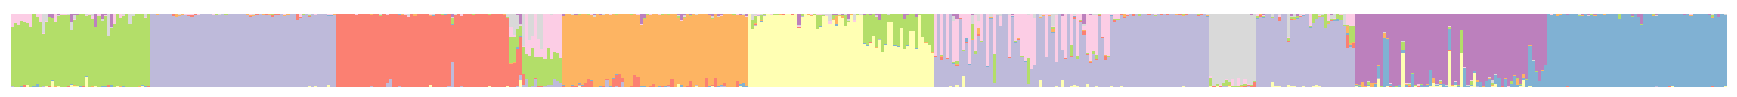

In [42]:
plt.figure()
pal = sns.color_palette("Set3").as_hex()[1:]

df = sampleorder[["Region", "Latitude", "Longitude",
                  0,1,2,3,4,5,6,7,8]].sort_values(["Region", "Longitude"], ascending = True)
df = df[["Region", 0,1,2,3,4,5,6,7,8]]
ax = df.plot.bar(stacked=True, 
                          figsize=(len(df)/25,1), 
                          width=1,
                          color=pal, 
                          fontsize='x-small',
                          edgecolor='black', 
                          linewidth=0, legend = False)

# these commands eliminate the bounding box for the barplot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# this controls rotation of the sample names along the x-axis
ax.set_xticklabels(df.index, rotation=45, ha='right')

# this controls the placement of the legend, as well as 
# font (fontsize), spacing (labelspacing), and bounding box (frameon)
ax.set_axis_off()
#plt.savefig("../structure_proportions_Mexico.pdf", dpi = 300, bbox_inches='tight')

In [55]:
sampleorder[["id"]][sampleorder["Region"] == "Florida"][sampleorder[6] > 0.5].to_csv("../FL_Cluster1.txt", index = False, header = None)

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_2176428/3157310933.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sampleorder[["id"]][sampleorder["Region"] == "Florida"][sampleorder[6] > 0.5].to_csv("../FL_Cluster1.txt", index = False, header = None)


In [56]:
sampleorder[["id"]][sampleorder["Region"] == "Florida"][sampleorder[1] > 0.5].to_csv("../FL_Cluster2_meso.txt", index = False, header = None)

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_2176428/3551476052.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sampleorder[["id"]][sampleorder["Region"] == "Florida"][sampleorder[1] > 0.5].to_csv("../FL_Cluster2_meso.txt", index = False, header = None)


In [158]:
!mkdir -p ../figures

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_2176428/2370893934.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

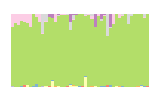

<Figure size 640x480 with 0 Axes>

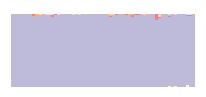

<Figure size 640x480 with 0 Axes>

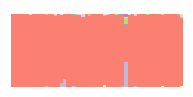

<Figure size 640x480 with 0 Axes>

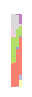

<Figure size 640x480 with 0 Axes>

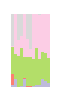

<Figure size 640x480 with 0 Axes>

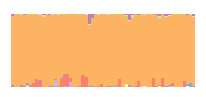

<Figure size 640x480 with 0 Axes>

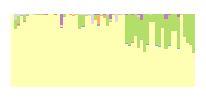

<Figure size 640x480 with 0 Axes>

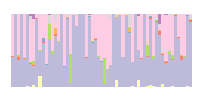

<Figure size 640x480 with 0 Axes>

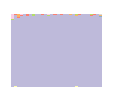

<Figure size 640x480 with 0 Axes>

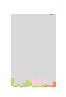

<Figure size 640x480 with 0 Axes>

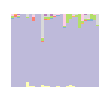

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

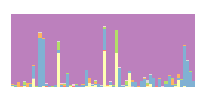

<Figure size 640x480 with 0 Axes>

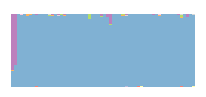

In [44]:
pal = sns.color_palette("Set3").as_hex()[1:]
for region in sampleorder.Region.unique():
    plt.figure()
    df = sampleorder[["Region", "Latitude", "Longitude",
                      0,1,2,3,4,5,6,7,8]][sampleorder["Region"] == region].sort_values(["Region", "Longitude"], ascending = True)
    df = df[["Region", 0,1,2,3,4,5,6,7,8]]
    ax = df.plot.bar(stacked=True, 
                              figsize=(len(df)/25,1), 
                              width=1,
                              color=pal, 
                              fontsize='x-small',
                              edgecolor='black', 
                              linewidth=0, legend = False)
    
    # these commands eliminate the bounding box for the barplot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # this controls rotation of the sample names along the x-axis
    ax.set_xticklabels(df.index, rotation=45, ha='right')
    
    # this controls the placement of the legend, as well as 
    # font (fontsize), spacing (labelspacing), and bounding box (frameon)
    ax.set_axis_off()
    plt.savefig("../figures/final_k9_structure_proportions_" + region + ".pdf", dpi = 300, bbox_inches='tight')